In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcbG9pY2hcRG9jdW1lbnRzXFdvcmtcR2l0aHViXHF1YXJ0b1xweXRob25faWFfcXVhcnRvXG1vZHVsZXNcbW9kdWxlXzAx'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\zipimport.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\codecs.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\aliases.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\__init__.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\utf_8.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\encodings\\cp1252.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\abc.py": 1727748220.0, "C:\\Users\\loich\\AppData\\Local\\Programs\\Python\\Python

In [2]:
#| label: setup
#| echo: true
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 12

print("✅ NumPy version :", np.__version__)
print("✅ Matplotlib prêt")

✅ NumPy version : 2.2.6
✅ Matplotlib prêt


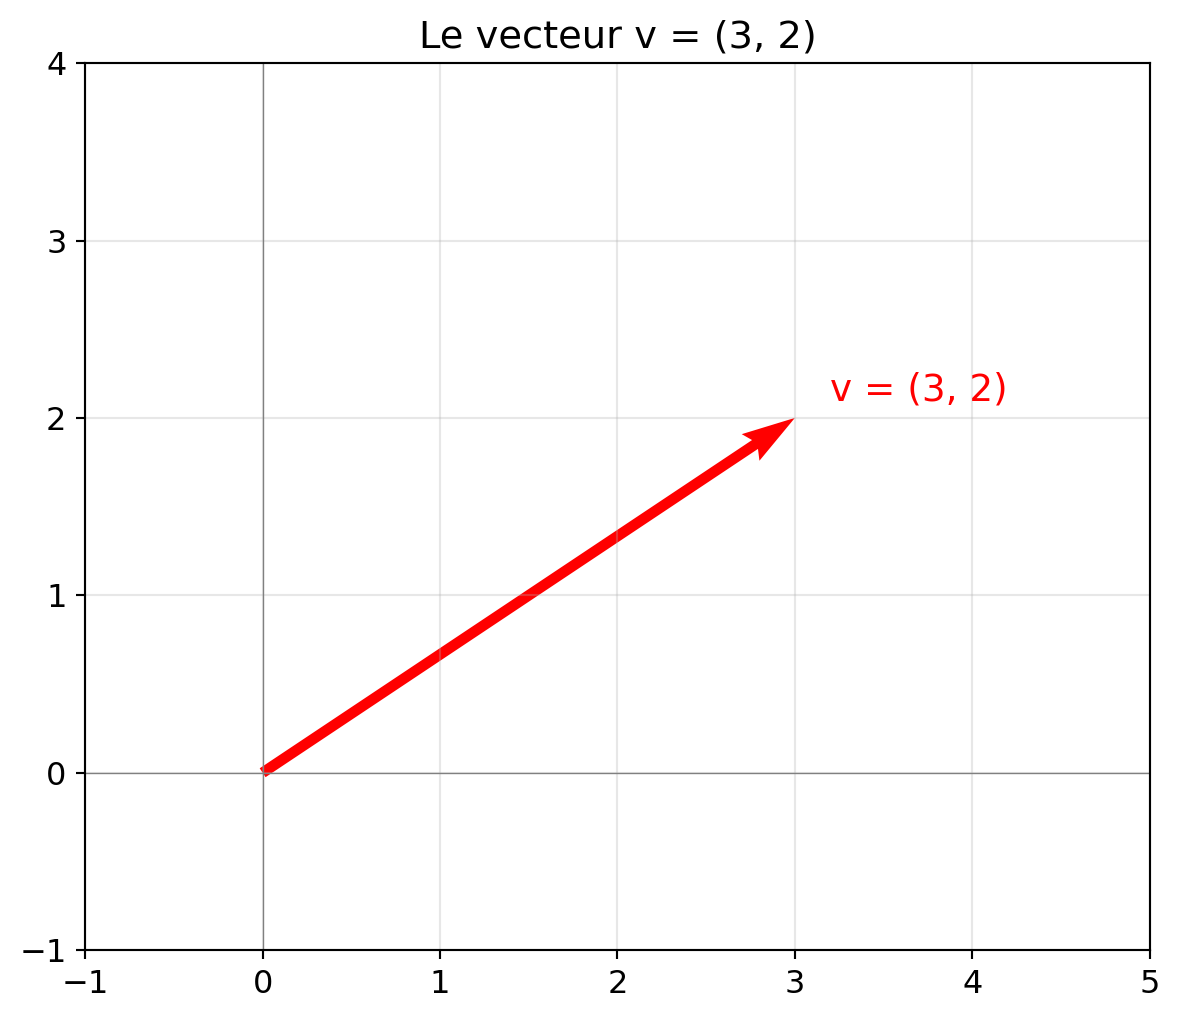

In [3]:
#| label: fig-vecteur-simple
#| fig-cap: Le vecteur v = (3, 2) représenté comme une flèche
fig, ax = plt.subplots()
ax.quiver(0, 0, 3, 2, angles='xy', scale_units='xy', scale=1, 
          color='red', width=0.01)
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 4)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.set_title("Le vecteur v = (3, 2)")
ax.annotate('v = (3, 2)', xy=(3, 2), xytext=(3.2, 2.1), 
            fontsize=14, color='red')
plt.show()

In [4]:
client_1 = [35, 42000, 2]   # âge=35, salaire=42000, enfants=2
client_2 = [52, 65000, 0]

print(f"Client 1 : {client_1}")
print(f"Client 2 : {client_2}")
print(f"Chaque client est un vecteur de {len(client_1)} dimensions")

Client 1 : [35, 42000, 2]
Client 2 : [52, 65000, 0]
Chaque client est un vecteur de 3 dimensions


In [5]:
# Addition en Python pur
u = [2, 1]
v = [1, 3]

# Méthode naïve : boucle
somme = []
for i in range(len(u)):
    somme.append(u[i] + v[i])
print(f"u + v = {somme}")

# Méthode plus pythonique
somme_bis = [u[i] + v[i] for i in range(len(u))]
print(f"u + v = {somme_bis}")

u + v = [3, 4]
u + v = [3, 4]


In [6]:
# Avec NumPy, c'est BEAUCOUP plus simple
u = np.array([2, 1])
v = np.array([1, 3])
print(f"u + v = {u + v}")

u + v = [3 4]


In [7]:
a = [2, 1]
b = [1, 3]
print(f"Listes Python : {a} + {b} = {a + b}  (concaténation !)")

a_np = np.array([2, 1])
b_np = np.array([1, 3])
print(f"Tableaux NumPy : {a_np} + {b_np} = {a_np + b_np}  (vraie addition)")

Listes Python : [2, 1] + [1, 3] = [2, 1, 1, 3]  (concaténation !)
Tableaux NumPy : [2 1] + [1 3] = [3 4]  (vraie addition)


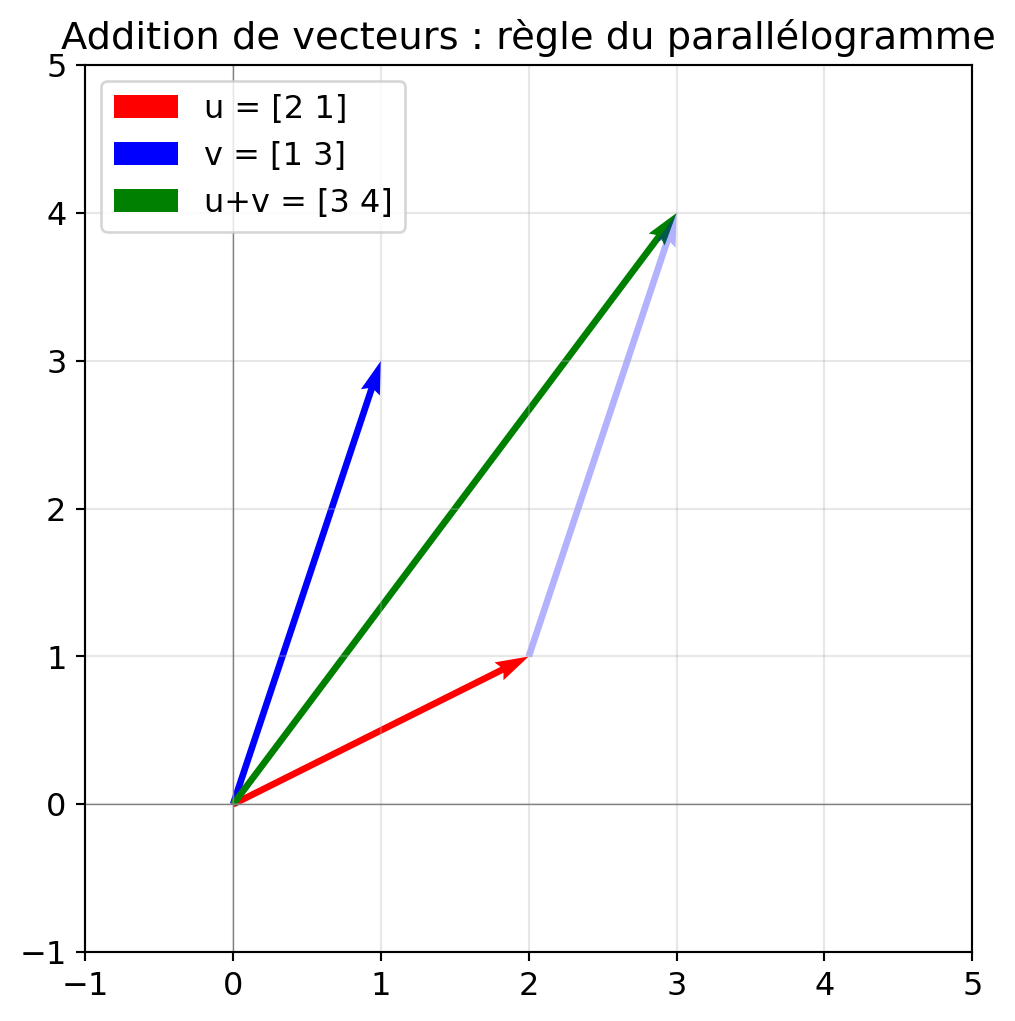

In [8]:
#| label: fig-parallelo
#| fig-cap: 'Addition de vecteurs : règle du parallélogramme'
fig, ax = plt.subplots()

u = np.array([2, 1])
v = np.array([1, 3])
somme = u + v

ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, 
          color='red', label=f'u = {u}')
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, 
          color='blue', label=f'v = {v}')
ax.quiver(0, 0, somme[0], somme[1], angles='xy', scale_units='xy', scale=1, 
          color='green', label=f'u+v = {somme}')
ax.quiver(u[0], u[1], v[0], v[1], angles='xy', scale_units='xy', scale=1, 
          color='blue', alpha=0.3)

ax.set_xlim(-1, 5)
ax.set_ylim(-1, 5)
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.legend(loc='upper left')
ax.set_title("Addition de vecteurs : règle du parallélogramme")
plt.show()

In [9]:
v = np.array([2, 1])
print(f"v       = {v}")
print(f"2 * v   = {2 * v}   (doublé)")
print(f"0.5 * v = {0.5 * v} (moitié)")
print(f"-1 * v  = {-1 * v}  (sens inverse)")

v       = [2 1]
2 * v   = [4 2]   (doublé)
0.5 * v = [1.  0.5] (moitié)
-1 * v  = [-2 -1]  (sens inverse)


In [10]:
#| eval: false
# TODO: Exercice 1 — à toi de jouer

# 1. Créer les deux vecteurs


# 2. Calculer a + b


# 3. Calculer 3 * a


# 4. Calculer a - b

In [11]:
# 1. Créer les deux vecteurs
a = np.array([4, 1, 3])
b = np.array([2, 5, 7])
print(f"a = {a}")
print(f"b = {b}")

# 2. Addition
print(f"a + b = {a + b}")

# 3. Multiplication scalaire
print(f"3 * a = {3 * a}")

# 4. Soustraction
print(f"a - b = {a - b}")

a = [4 1 3]
b = [2 5 7]
a + b = [ 6  6 10]
3 * a = [12  3  9]
a - b = [ 2 -4 -4]


In [12]:
# Produit scalaire à la main
u = [1, 2, 3]
v = [4, 5, 6]

resultat = 0
for i in range(len(u)):
    resultat += u[i] * v[i]
print(f"u · v = {u[0]}×{v[0]} + {u[1]}×{v[1]} + {u[2]}×{v[2]} = {resultat}")

u · v = 1×4 + 2×5 + 3×6 = 32


In [13]:
# Avec NumPy : trois syntaxes équivalentes
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

print(f"np.dot(u, v) = {np.dot(u, v)}")
print(f"u @ v        = {u @ v}")
print(f"u.dot(v)     = {u.dot(v)}")

np.dot(u, v) = 32
u @ v        = 32
u.dot(v)     = 32


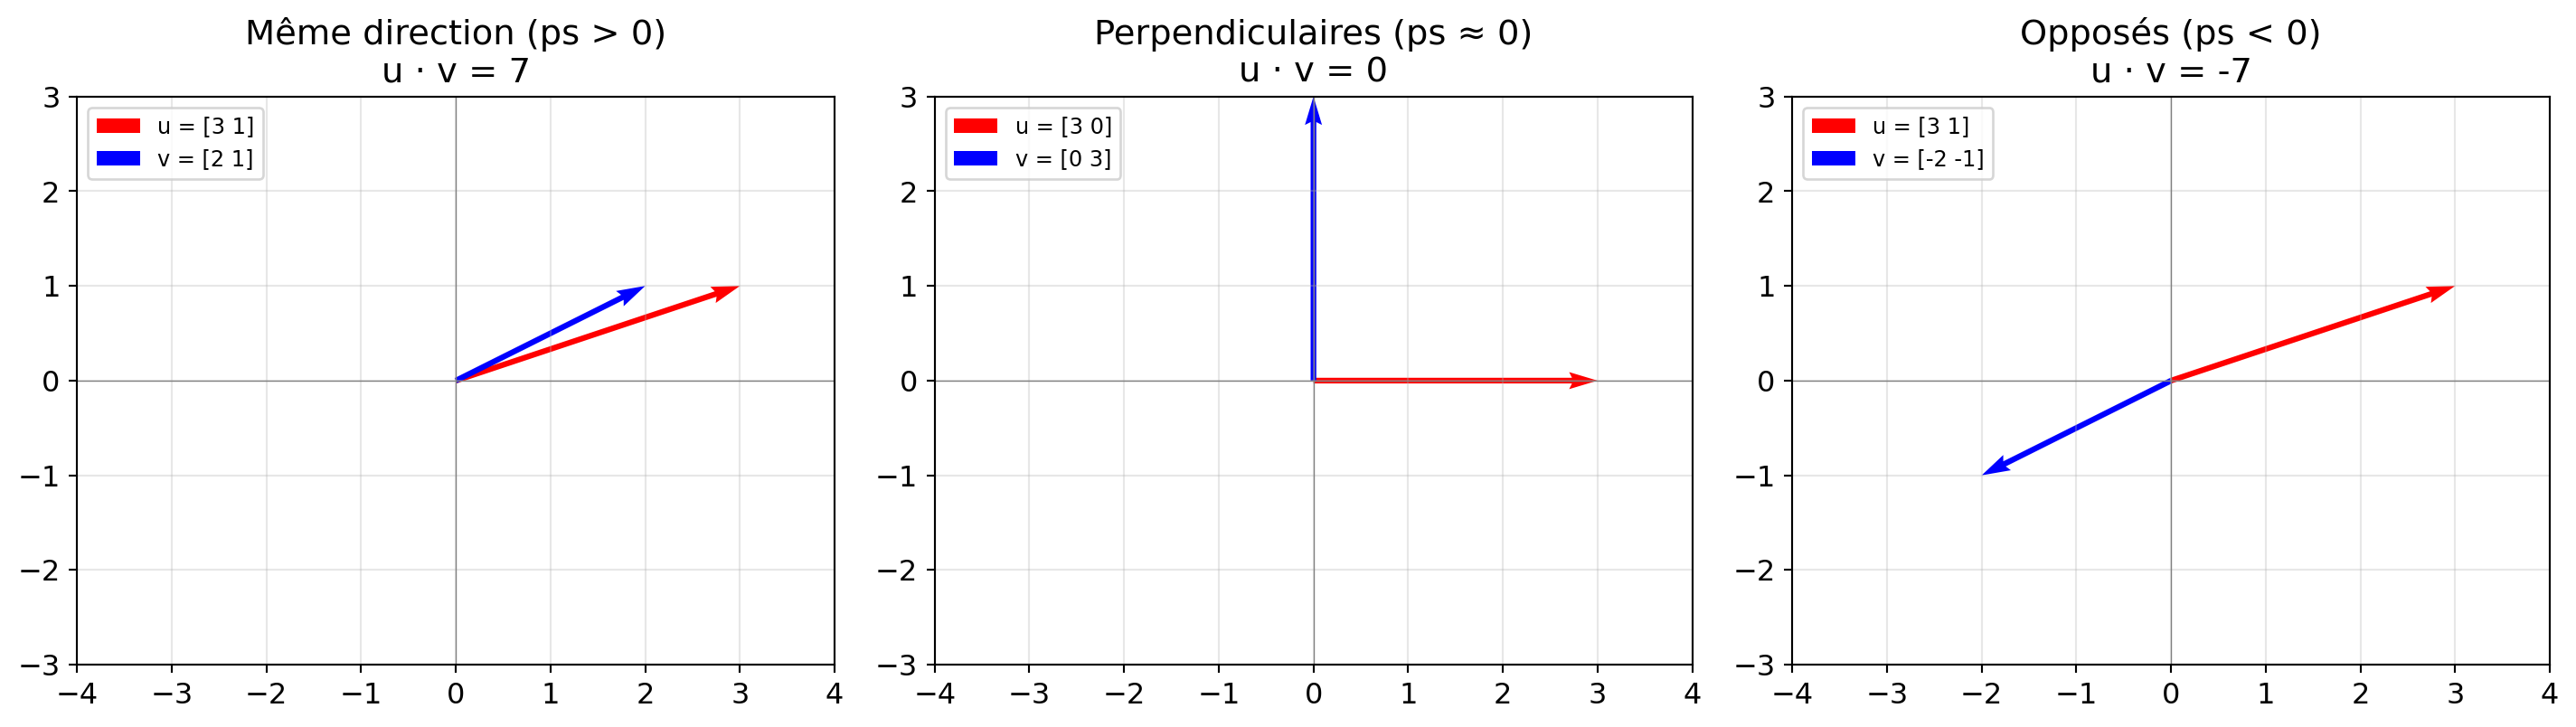

In [14]:
#| label: fig-produit-scalaire
#| fig-cap: Trois cas d'interprétation du produit scalaire
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

cas = [
    ("Même direction (ps > 0)", np.array([3, 1]), np.array([2, 1])),
    ("Perpendiculaires (ps ≈ 0)", np.array([3, 0]), np.array([0, 3])),
    ("Opposés (ps < 0)", np.array([3, 1]), np.array([-2, -1])),
]

for ax, (titre, u, v) in zip(axes, cas):
    ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1, 
              color='red', label=f'u = {u}')
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, 
              color='blue', label=f'v = {v}')
    ps = np.dot(u, v)
    ax.set_title(f"{titre}\nu · v = {ps}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-3, 3)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.axvline(x=0, color='gray', linewidth=0.5)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

In [15]:
client_A = np.array([1, 9, 8, 2])  # aime sport et tech
client_B = np.array([2, 8, 9, 1])  # aime sport et tech aussi
client_C = np.array([9, 1, 2, 9])  # aime bio et mode

print(f"A et B : produit scalaire = {np.dot(client_A, client_B)}")
print(f"A et C : produit scalaire = {np.dot(client_A, client_C)}")
print()
print("➡️ A et B sont bien plus similaires que A et C.")

A et B : produit scalaire = 148
A et C : produit scalaire = 52

➡️ A et B sont bien plus similaires que A et C.


In [16]:
#| eval: false
# TODO: Exercice 2

# 1. Créer les trois vecteurs


# 2. Calculer les 3 produits scalaires


In [17]:
doc_1 = np.array([8, 0, 0, 7, 3])  # tuto Python
doc_2 = np.array([0, 9, 8, 0, 0])  # livre de cuisine
doc_3 = np.array([6, 0, 0, 5, 9])  # cours de ML

print(f"Similarité doc_1 et doc_2 : {np.dot(doc_1, doc_2)}")
print(f"Similarité doc_1 et doc_3 : {np.dot(doc_1, doc_3)}")
print(f"Similarité doc_2 et doc_3 : {np.dot(doc_2, doc_3)}")

Similarité doc_1 et doc_2 : 0
Similarité doc_1 et doc_3 : 110
Similarité doc_2 et doc_3 : 0


In [18]:
v = np.array([3, 4])

norme_manuelle = np.sqrt(v[0]**2 + v[1]**2)
print(f"Norme de {v} à la main : {norme_manuelle}")

norme_numpy = np.linalg.norm(v)
print(f"Norme de {v} avec NumPy : {norme_numpy}")

Norme de [3 4] à la main : 5.0
Norme de [3 4] avec NumPy : 5.0


In [19]:
a = np.array([1, 2])
b = np.array([4, 6])

distance = np.linalg.norm(a - b)
print(f"Distance euclidienne : {distance}")

Distance euclidienne : 5.0


In [20]:
a = np.array([1, 2])
b = np.array([4, 6])

d_manhattan = np.sum(np.abs(a - b))
d_euclid = np.linalg.norm(a - b)
d_cheby = np.max(np.abs(a - b))

print(f"Distance de Manhattan : {d_manhattan}")
print(f"Distance euclidienne  : {d_euclid:.2f}")
print(f"Distance de Chebyshev : {d_cheby}")

Distance de Manhattan : 7
Distance euclidienne  : 5.00
Distance de Chebyshev : 4


In [21]:
M = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
])

print("Matrice M :")
print(M)
print(f"\nTaille : {M.shape}  (lignes, colonnes)")
print(f"Accéder à M[1, 0] (2e ligne, 1re colonne) : {M[1, 0]}")

Matrice M :
[[1 2]
 [3 4]
 [5 6]]

Taille : (3, 2)  (lignes, colonnes)
Accéder à M[1, 0] (2e ligne, 1re colonne) : 3


In [22]:
donnees = np.array([
    [35, 42000, 2, 1],   # Client 1
    [52, 65000, 0, 1],   # Client 2
    [28, 31000, 1, 0],   # Client 3
])

print(f"Jeu de données {donnees.shape} :")
print(donnees)
print(f"\nClient 2 : {donnees[1]}")
print(f"Colonne salaire : {donnees[:, 1]}")

Jeu de données (3, 4) :
[[   35 42000     2     1]
 [   52 65000     0     1]
 [   28 31000     1     0]]

Client 2 : [   52 65000     0     1]
Colonne salaire : [42000 65000 31000]


In [23]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

print("A @ B =")
print(A @ B)
print()
print("Vérification du premier élément :")
print(f"(A×B)[0,0] = ligne 0 de A · colonne 0 de B")
print(f"         = [1,2] · [5,7] = 1×5 + 2×7 = {1*5 + 2*7}")

A @ B =
[[19 22]
 [43 50]]

Vérification du premier élément :
(A×B)[0,0] = ligne 0 de A · colonne 0 de B
         = [1,2] · [5,7] = 1×5 + 2×7 = 19


In [24]:
# Attention : A @ B ≠ B @ A (non commutatif !)
print("A @ B =")
print(A @ B)
print("\nB @ A =")
print(B @ A)

A @ B =
[[19 22]
 [43 50]]

B @ A =
[[23 34]
 [31 46]]


In [25]:
#| eval: false
# TODO: Exercice 3

In [26]:
ingredients = np.array([
    [50, 30, 5],   # croissant
    [60, 35, 8],   # pain au choc
    [80, 40, 10],  # chausson
])

commandes = np.array([20, 15, 10])

totaux = commandes @ ingredients

noms = ["Farine", "Beurre", "Sucre"]
print("📋 Quantités à préparer pour la journée :\n")
for nom, quantite in zip(noms, totaux):
    print(f"  {nom:10s} : {quantite:5d} g")

📋 Quantités à préparer pour la journée :

  Farine     :  2700 g
  Beurre     :  1525 g
  Sucre      :   320 g


In [27]:
M = np.array([[1, 2, 3], [4, 5, 6]])
print(f"M (taille {M.shape}) :")
print(M)
print(f"\nM.T (taille {M.T.shape}) :")
print(M.T)

M (taille (2, 3)) :
[[1 2 3]
 [4 5 6]]

M.T (taille (3, 2)) :
[[1 4]
 [2 5]
 [3 6]]


In [28]:
A = np.array([[4, 7], [2, 6]])

A_inv = np.linalg.inv(A)
print("A⁻¹ :")
print(A_inv)

print("\nA @ A⁻¹ doit donner la matrice identité :")
print(np.round(A @ A_inv, 10))

A⁻¹ :
[[ 0.6 -0.7]
 [-0.2  0.4]]

A @ A⁻¹ doit donner la matrice identité :
[[ 1. -0.]
 [-0.  1.]]


In [29]:
A = np.array([[4, 7], [2, 6]])
B = np.array([[2, 4], [1, 2]])  # lignes proportionnelles

print(f"det(A) = {np.linalg.det(A):.2f}")
print(f"det(B) = {np.linalg.det(B):.2f}  (proche de 0 → pas d'inverse)")

det(A) = 10.00
det(B) = 0.00  (proche de 0 → pas d'inverse)


In [30]:
#| eval: false
# TODO: Exercice bilan

fruits_connus = np.array([
    [150, 8], [140, 9], [160, 2], [170, 1], [200, 5],
])
etiquettes = ["pomme rouge", "pomme rouge", "pomme verte", 
              "pomme verte", "orange"]
nouveau_fruit = np.array([155, 9])

# 1. Distances


# 2. Indice du plus proche


# 3. Classe prédite

In [31]:
fruits_connus = np.array([
    [150, 8], [140, 9], [160, 2], [170, 1], [200, 5],
])
etiquettes = ["pomme rouge", "pomme rouge", "pomme verte", 
              "pomme verte", "orange"]
nouveau_fruit = np.array([155, 9])

# 1. Distances (broadcasting NumPy)
differences = fruits_connus - nouveau_fruit
distances = np.linalg.norm(differences, axis=1)

print("Distances au nouveau fruit :")
for i, (etiq, dist) in enumerate(zip(etiquettes, distances)):
    print(f"  Fruit {i} ({etiq:15s}) : {dist:.2f}")

# 2. Indice du plus proche
indice = np.argmin(distances)

# 3. Prédiction
print(f"\n🎯 Prédiction pour {nouveau_fruit} : {etiquettes[indice]}")

Distances au nouveau fruit :
  Fruit 0 (pomme rouge    ) : 5.10
  Fruit 1 (pomme rouge    ) : 15.00
  Fruit 2 (pomme verte    ) : 8.60
  Fruit 3 (pomme verte    ) : 17.00
  Fruit 4 (orange         ) : 45.18

🎯 Prédiction pour [155   9] : pomme rouge
